# **IMC Round 3/4 Algorithmic and Manual Data Analysis**

## Imports

In [2]:
# change path so notebook sees root 
import sys 
import os 
global_path = os.path.abspath('/Users/amjadsaidam/Desktop/Quant stuff /IMC ')
full_path = os.path.join(global_path, 'ROUND_1_2')
for p in [global_path, full_path]:
    if p not in sys.path:
        sys.path.insert(0, p)

# general
import os
import numpy as np 
import pandas as pd 
# specifc files from directory
from ROUND_1_2.code import data_pre_processing as data_pre_prep
from ROUND_1_2.code import eda_functions as eda
# eda 
import matplotlib.pyplot as plt 

## Data

In [4]:
data_l2_book_paths = [ 
    '/Users/amjadsaidam/Desktop/Quant stuff /IMC /ROUND_3_4/data_round_4/prices_round_4_day_1.csv', 
    '/Users/amjadsaidam/Desktop/Quant stuff /IMC /ROUND_3_4/data_round_4/prices_round_4_day_2.csv',
    '/Users/amjadsaidam/Desktop/Quant stuff /IMC /ROUND_3_4/data_round_4/prices_round_4_day_3.csv'
]

data_market_trades_paths = [
    '/Users/amjadsaidam/Desktop/Quant stuff /IMC /ROUND_3_4/data_round_4/trades_round_4_day_1.csv', 
    '/Users/amjadsaidam/Desktop/Quant stuff /IMC /ROUND_3_4/data_round_4/trades_round_4_day_2.csv',
    '/Users/amjadsaidam/Desktop/Quant stuff /IMC /ROUND_3_4/data_round_4/trades_round_4_day_3.csv'
]

def data_pre_process_pipeline(paths: list[str], book = True):
    """
    data cleaning pipeline
    """
    df_clean: dict = {}
    df = data_pre_prep.read_data(paths, book)
    for k in df.keys():
        #data_pre_prep.standerdise_timestamp(df[k]) # inplace 
        if book: 
            data_pre_prep.clean_book(df[k])
            df[k] = data_pre_prep.total_vols(df[k])
            df[k] = data_pre_prep.mid_returns(df[k])
        df_clean[k] = df[k]
    
    return df_clean

# data time 
t = 1e-4 * (1/24*60*60)

# call 
l2_book_by_asset =  data_pre_process_pipeline(data_l2_book_paths)
market_orders_by_l2_book = data_pre_process_pipeline(data_market_trades_paths, False)

# seperate equities and options
eqs = ['VELVETFRUIT_EXTRACT', 'HYDROGEL_PACK']
def options_equities(data, equities):
    eqs = {}
    for eq in equities:
        eqs[eq] = data[eq]
        data.pop(eq)

    return eqs, data 

# call 
l2_equities, l2_options = options_equities(l2_book_by_asset, eqs)
market_trades_equities, market_trades_options = options_equities(market_orders_by_l2_book, eqs)

## EDA

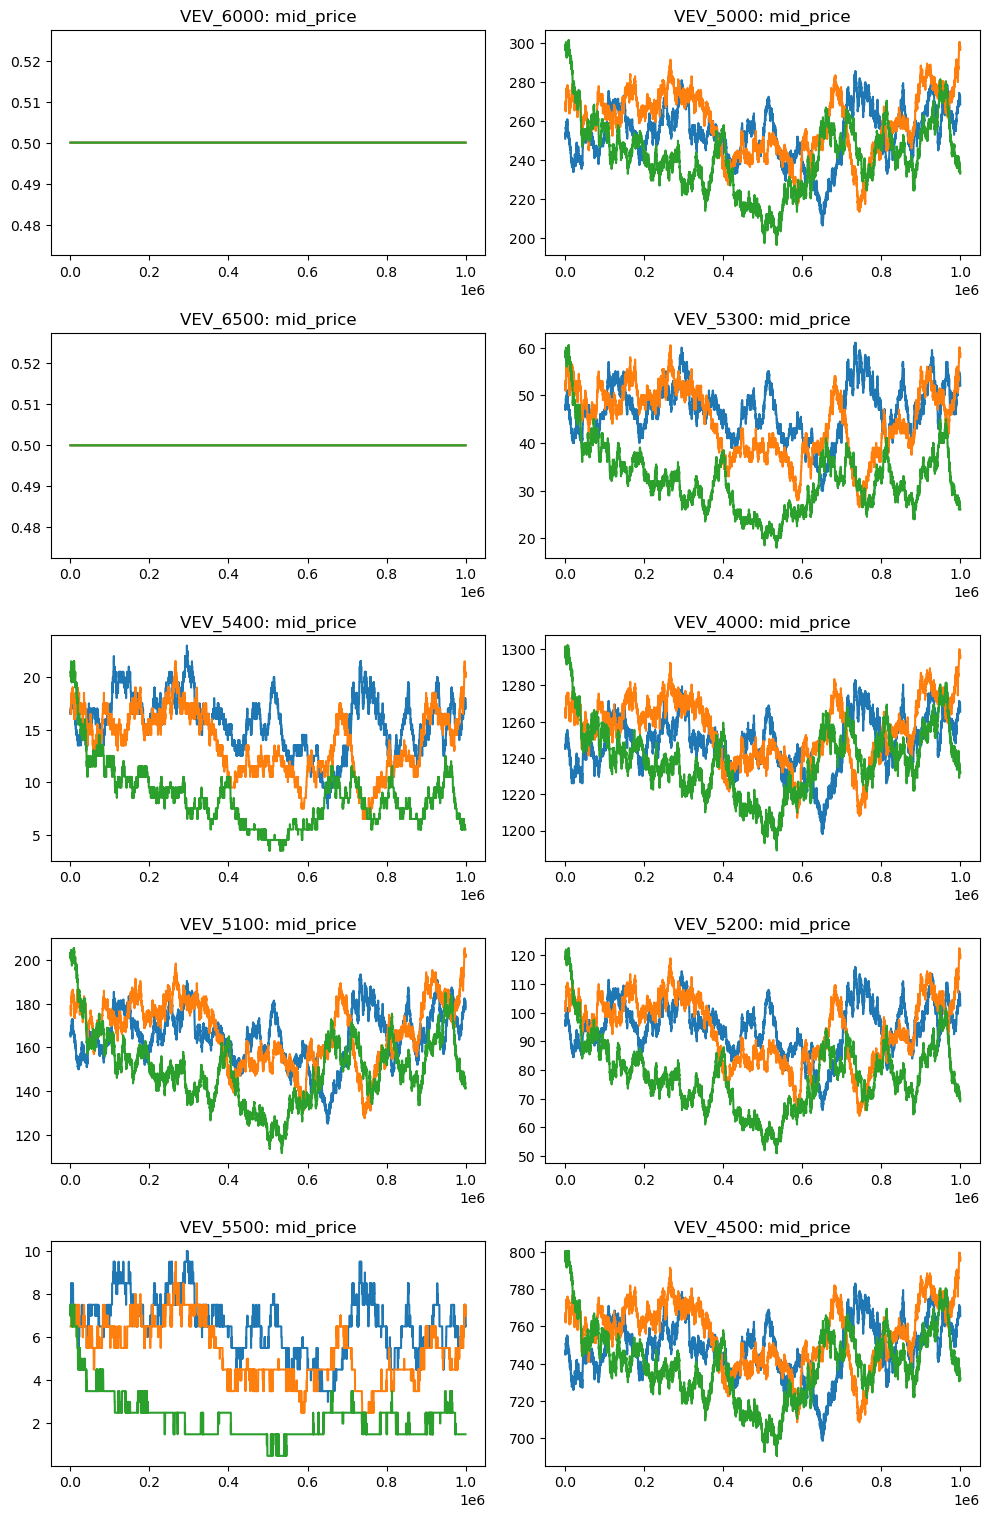

In [8]:
def plot_features(data: dict[pd.DataFrame], feature: str, sw, sh): 
    n = len(data)
    plt.figure(figsize = (sw, sh))
    for i, (k, v) in enumerate(data.items()): 
        ax = plt.subplot(n, 2, i+1)
        eda.plot_features(v, feature, plt)
        ax.set_title(f'{k}: {feature}')
    plt.tight_layout()
    plt.show();

# options
plot_features(l2_options, 'mid_price', 10, 30)

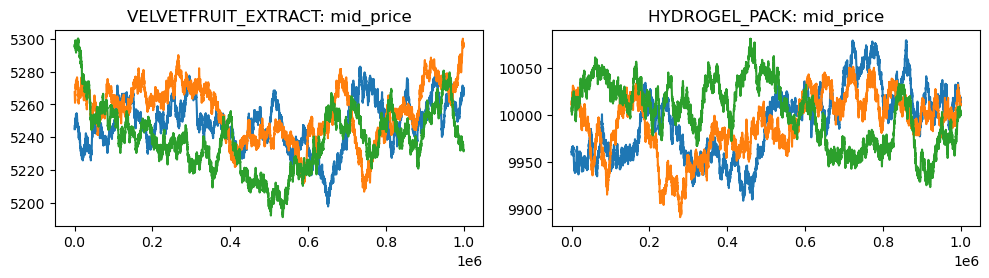

In [9]:
plot_features(l2_equities, 'mid_price', 10, 5)

## Realised Volatility Estimate

In [10]:
# underlying volatility
opt_underlying = l2_equities['VELVETFRUIT_EXTRACT']

n = opt_underlying.shape[0] # 3 days data 

rt = np.diff(np.log(opt_underlying.loc[:, 'mid_price'].values))

daily_vol = np.std(rt, ddof = 1)*np.sqrt(n/3) # daily vol 

# annualised vol
yearly_vol = daily_vol*np.sqrt(252)

print('empirical annulsied RV =', yearly_vol)

empirical annulsied RV = 0.344131773432916


## Market Quantity

In [11]:
def l2_and_market(l2_book, l2_trades):
    return pd.merge(l2_book, l2_trades, on = 'timestemp', how = 'left')

def full_l2_book(l2_books: dict[str, pd.DataFrame], l2_trades: dict[str, pd.DataFrame]):
    book_market = {}
    for product in l2_books.keys():
        book = l2_books.get(product)
        market = l2_trades.get(product)
        book_market[product] = pd.merge(book, 
                                        market, 
                                        on = ['day', 'timestamp'], 
                                        how = 'left').fillna(0)
        data_pre_prep.standerdise_timestamp(book_market[product])
    
    return book_market

# build combined books 
opt_comb_book = full_l2_book(l2_options, market_trades_options)
eq_comb_book = full_l2_book(l2_equities, market_trades_equities)

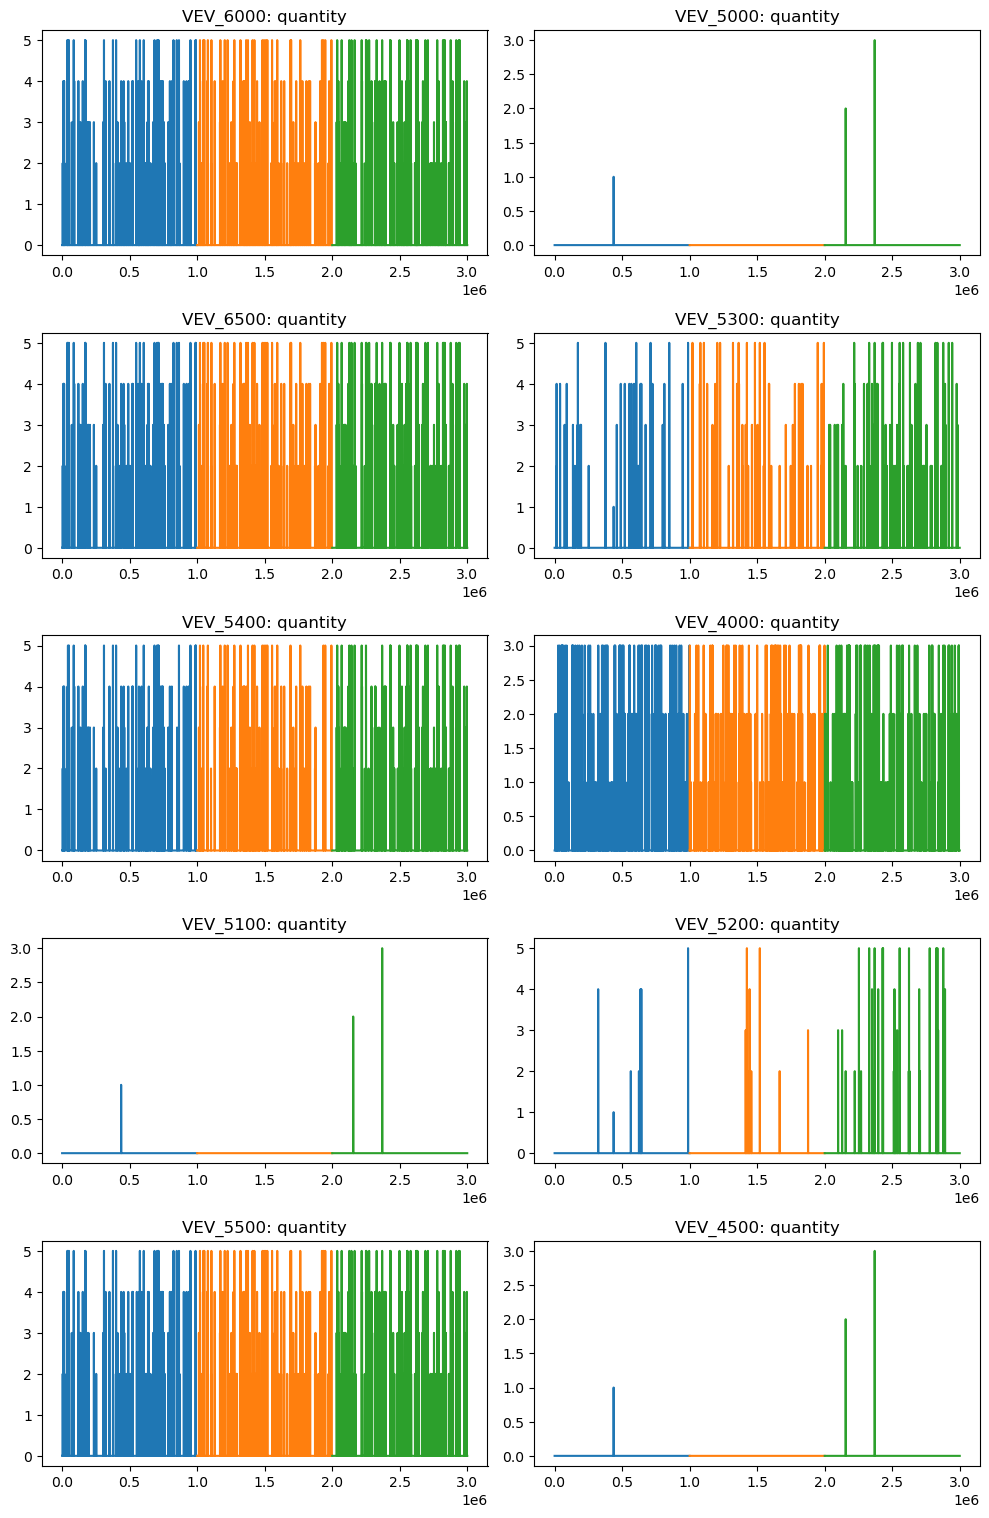

In [12]:
plot_features(opt_comb_book, 'quantity', 10, 30)

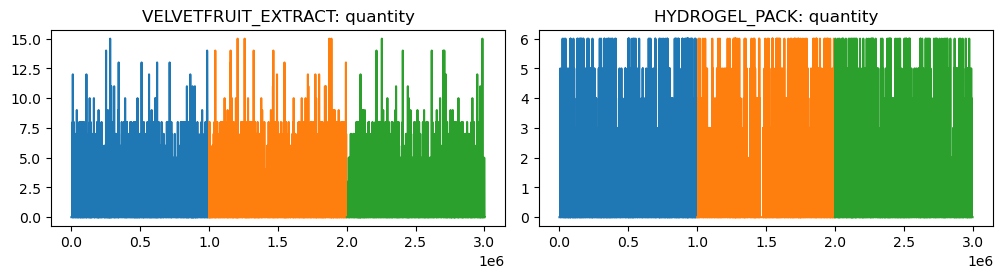

In [13]:
plot_features(eq_comb_book, 'quantity', 10, 5)

## Expected Market Moves by Trader

In [14]:
# expectations
def impact(data: pd.DataFrame, buy = True):
        """
        empirical expectations of future market direction conditioned on trades of market participant
        E[r_t+1 > 0 | buyer_i,t]
        """
        data['mid_returns'] = data['mid_returns'].shift(-1).fillna(0) # future returns 
        n, m = data.shape
        mask = data['mid_returns']<0
        if buy:
             mask = data['mid_returns']>0

        return len(data.loc[mask, 'mid_returns']) / n
    
def expected_trader_impact(data: pd.DataFrame):
    """
    all assets
    """
    buy_p_imp, sell_p_imp = {}, {}
    buyers = data['buyer'].unique()
    sellers = data['seller'].unique()
    
    for b in buyers:
        if b == 0:
             continue
        sub = data.loc[data['buyer'] == b, ['mid_returns', 'quantity']]
        buy_p_imp[b] = impact(sub)
    
    for s in sellers:
        if s == 0:
             continue
        sub = data.loc[data['seller'] == s, ['mid_returns', 'quantity']]
        sell_p_imp[s] = impact(sub)
    
    return {'buyer': buy_p_imp, 'seller': sell_p_imp}

def assets_expected_tarder_impact(data: dict[str, pd.DataFrame]):
    asset_p_imps = {}
    for k, v in data.items():
         asset_p_imps[k] = expected_trader_impact(v)
    
    return asset_p_imps

# execpted price increase from different market participants
eq_price_impacts = assets_expected_tarder_impact(eq_comb_book)

print('Buy Side: Probability of Price Increase Given Trader')
print(eq_price_impacts['HYDROGEL_PACK']['buyer'])

print('Sell Side: Probability of Price Decrease Given Trader')
print(eq_price_impacts['HYDROGEL_PACK']['seller'])

Buy Side: Probability of Price Increase Given Trader
{'Mark 38': 0.43106796116504853, 'Mark 14': 0.3911290322580645, 'Mark 22': 0.9090909090909091}
Sell Side: Probability of Price Decrease Given Trader
{'Mark 22': 0.0, 'Mark 14': 0.4378698224852071, 'Mark 38': 0.40433925049309666}


## Market Making

2065.0
-2031.0


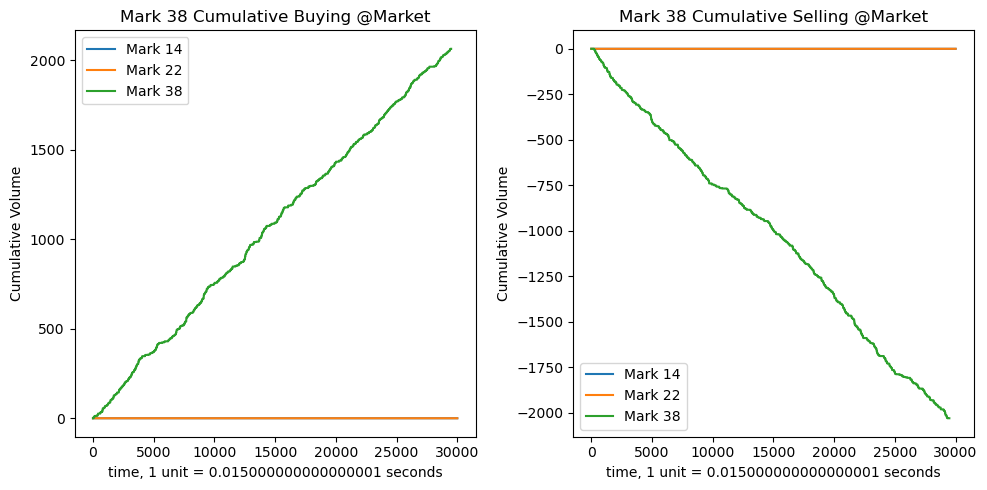

In [17]:
def market_order_side(data):
    """
    determines if the market order was an aggresive buyer or seller
    """
    data['trader'] = np.where(
        data['ask_price_1'] == data['price'], 
        data['buyer'], 
        np.where(
            data['bid_price_1'] == data['price'], 
            data['seller'], 
            0
        )
    )

    return data

def market_maker(data: pd.DataFrame, trader: str = 'Mark 38'):
    """
    calculates the cumulative sum of order quantity for any trader
    """
    buy_pyramid = []
    sell_pyramid = [] 
    net_flow = []

    qty = data.loc[:, 'quantity']

    T = data.shape[0]
    for t in range(T):
        qty_t = qty.iloc[t]
        market_particiapnt = data.loc[:, 'trader'].iloc[t]
        if market_particiapnt == trader:
            if data.loc[:, 'buyer'].iloc[t] == trader: 
                buy_pyramid.append(qty_t)
                net_flow.append(qty_t)
            elif data.loc[:, 'seller'].iloc[t] == trader:
                sell_pyramid.append(-qty_t)
                net_flow.append(-qty_t)
        else:
            buy_pyramid.append(0)
            sell_pyramid.append(0)
            net_flow.append(0)

    return np.cumsum(buy_pyramid), np.cumsum(sell_pyramid), np.cumsum(net_flow)


# focus on hydrogel product
hydro = market_order_side(eq_comb_book['HYDROGEL_PACK'])

mark_14_buys, mark_14_sells, _ = market_maker(hydro, 'Mark 14')
mark_22_buys, mark_22_sells, _ = market_maker(hydro, 'Mark 22')
mark_38_buys, mark_38_sells, net_flow = market_maker(hydro)

# plots
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 5))
# buys 
ax[0].set_title('Mark 38 Cumulative Buying @Market')
ax[0].plot(mark_14_buys)
ax[0].plot(mark_22_buys)
ax[0].plot(mark_38_buys)
ax[0].set_ylabel('Cumulative Volume')
ax[0].set_xlabel(f'time, 1 unit = {t} seconds')
ax[0].legend(['Mark 14', 'Mark 22', 'Mark 38'])
# sells
ax[1].set_title('Mark 38 Cumulative Selling @Market')
ax[1].plot(mark_14_sells)
ax[1].plot(mark_22_sells)
ax[1].plot(mark_38_sells)
ax[1].set_ylabel('Cumulative Volume')
ax[1].set_xlabel(f'time, 1 unit = {t} seconds')
ax[1].legend(['Mark 14', 'Mark 22', 'Mark 38'])
plt.tight_layout();

print(mark_38_buys[-1])
print(mark_38_sells[-1])

In [23]:
hydro.loc[hydro['buyer'] != 0, :]

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,total_bid_volume,total_ask_volume,mid_returns,buyer,seller,symbol,currency,price,quantity,trader
51,0,5100,HYDROGEL_PACK,9952,11,9950.0,26.0,0.0,0.0,9960,...,37.0,41.0,-0.000602,Mark 38,Mark 22,HYDROGEL_PACK,XIRECS,9960.0,4.0,Mark 38
62,0,6200,HYDROGEL_PACK,9939,12,9937.0,29.0,0.0,0.0,9955,...,41.0,41.0,-0.000201,Mark 38,Mark 14,HYDROGEL_PACK,XIRECS,9955.0,5.0,Mark 38
150,0,15000,HYDROGEL_PACK,9951,13,9948.0,25.0,0.0,0.0,9966,...,38.0,38.0,0.000050,Mark 38,Mark 14,HYDROGEL_PACK,XIRECS,9966.0,4.0,Mark 38
228,0,22800,HYDROGEL_PACK,9946,12,9944.0,26.0,0.0,0.0,9962,...,38.0,38.0,-0.000402,Mark 14,Mark 38,HYDROGEL_PACK,XIRECS,9946.0,6.0,Mark 38
308,0,30800,HYDROGEL_PACK,9940,10,9937.0,29.0,0.0,0.0,9956,...,39.0,39.0,0.000201,Mark 14,Mark 38,HYDROGEL_PACK,XIRECS,9940.0,2.0,Mark 38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29809,2,2980900,HYDROGEL_PACK,9958,14,9956.0,27.0,0.0,0.0,9974,...,41.0,41.0,-0.000501,Mark 38,Mark 14,HYDROGEL_PACK,XIRECS,9974.0,2.0,Mark 38
29828,2,2982800,HYDROGEL_PACK,9965,10,9962.0,30.0,0.0,0.0,9981,...,40.0,40.0,0.000301,Mark 14,Mark 38,HYDROGEL_PACK,XIRECS,9965.0,3.0,Mark 38
29862,2,2986200,HYDROGEL_PACK,9957,13,9954.0,25.0,0.0,0.0,9973,...,38.0,38.0,-0.000301,Mark 38,Mark 14,HYDROGEL_PACK,XIRECS,9973.0,3.0,Mark 38
29898,2,2989800,HYDROGEL_PACK,9977,15,9975.0,21.0,0.0,0.0,9993,...,36.0,36.0,0.000100,Mark 38,Mark 14,HYDROGEL_PACK,XIRECS,9993.0,5.0,Mark 38


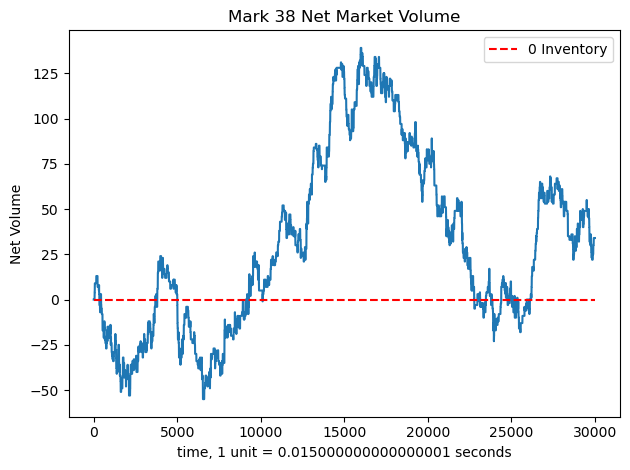

In [21]:
plt.title('Mark 38 Net Market Volume')
plt.plot(net_flow)
plt.ylabel('Net Volume')
plt.xlabel(f'time, 1 unit = {t} seconds')
plt.hlines(0, 0, n, color = 'r', linestyles = '--', label = '0 Inventory')
plt.legend()
plt.tight_layout();

In [214]:
net_flow_pos = net_flow[net_flow > 0]
net_flow_neg = net_flow[net_flow < 0]

q3_pos = np.percentile(net_flow_pos, 75)
q3_neg = np.percentile(net_flow_neg, 25)

print(q3_pos)
print(q3_neg)

86.0
-33.0


## ROUND 3 Manual Trading Round Order Book Simulation

In [ ]:
from scipy.stats import skewnorm

bl, bh = 670, 920
b_range = list(range(bl, bh+5, 5)) # support of bid density
b_exp = .5*(bl+bh)

rev_p_density = lambda rev_p: skewnorm.pdf(x = rev_p, loc = b_exp, scale = bh-bl, a = 3)

# optimal b1
b1_star = 0
obj_star = -np.inf 
for b in b_range:
    density = rev_p_density(b)
    pnl = bh - b
    obj = density*pnl
    if obj>obj_star:
        obj_star = obj 
        b1_star = b 
print('optimal first bid (b1):', b1_star)

# optimal b2 (NOT IMPLEMENTED)
pnl_pen = lambda b2, b2_avg: np.power((bh - b2_avg)/(bh - b2), 3)

# market regime transition probabilty matrix (gives probs os avergae bid in different market regimes)
# pi_s = transitio probability matrix

# weighted long run state transition, weighting pnl by this matrix will give expected pnl given different strategies being employed
# E[Pi_(d2)] = sum_s Pi_d2( d2 | S = s) * pi_s, 

# arg max of expcted long run transition pnl, b2 that maximised expection of pnl over different market regimes is best second bid

# plot 
sims = int(1e3)
# bids denisty
b_dens = np.random.uniform(bl, bh, sims)

# reserve price density 
rvs = np.linspace(bl, bh, sims)
dens = [rev_p_density(rv) for rv in rvs]

optimal first bid (b1): 805


## ROUND 4 Manual

In [ ]:
import numpy as np
from scipy.optimize import milp, LinearConstraint, Bounds


def solve_option_milp(payoff_by_state, probs, v_max, min_trade=1e-6):
    """
    """

    payoff_by_state = np.asarray(payoff_by_state, dtype=float)
    probs = np.asarray(probs, dtype=float)
    v_max = np.asarray(v_max, dtype=float)

    n_states, n_options = payoff_by_state.shape

    # Expected payoff per unit volume for each option
    mu = probs @ payoff_by_state

    # Variables:
    # [L_1,...,L_n, S_1,...,S_n, y_1,...,y_n]
    n_vars = 3 * n_options

    L = np.arange(n_options)
    S = np.arange(n_options, 2 * n_options)
    y = np.arange(2 * n_options, 3 * n_options)

    # scipy.milp minimizes, so maximize mu*L - mu*S by minimizing negative
    c = np.zeros(n_vars)
    c[L] = -mu
    c[S] = mu

    # Bounds
    lb = np.zeros(n_vars)
    ub = np.full(n_vars, np.inf)

    ub[L] = v_max
    ub[S] = v_max
    ub[y] = 1

    bounds = Bounds(lb, ub)

    # y variables are binary/integer
    integrality = np.zeros(n_vars)
    integrality[y] = 1

    A = []
    lower = []
    upper = []

    for i in range(n_options):
        # L_i <= v_max_i * y_i
        row = np.zeros(n_vars)
        row[L[i]] = 1
        row[y[i]] = -v_max[i]
        A.append(row)
        lower.append(-np.inf)
        upper.append(0)

        # S_i <= v_max_i * (1 - y_i)
        # S_i + v_max_i*y_i <= v_max_i
        row = np.zeros(n_vars)
        row[S[i]] = 1
        row[y[i]] = v_max[i]
        A.append(row)
        lower.append(-np.inf)
        upper.append(v_max[i])

        # Optional: if long selected, force strictly positive long volume
        # L_i >= min_trade * y_i
        row = np.zeros(n_vars)
        row[L[i]] = 1
        row[y[i]] = -min_trade
        A.append(row)
        lower.append(0)
        upper.append(np.inf)

        # Optional: if short selected, force strictly positive short volume
        # S_i >= min_trade * (1 - y_i)
        # S_i + min_trade*y_i >= min_trade
        row = np.zeros(n_vars)
        row[S[i]] = 1
        row[y[i]] = min_trade
        A.append(row)
        lower.append(min_trade)
        upper.append(np.inf)

    constraints = LinearConstraint(np.vstack(A), np.array(lower), np.array(upper))

    res = milp(
        c=c,
        integrality=integrality,
        bounds=bounds,
        constraints=constraints,
        options={"mip_rel_gap": 0.0}
    )

    if not res.success:
        raise RuntimeError(res.message)

    sol = res.x

    long_volume = sol[L]
    short_volume = sol[S]
    side = np.where(long_volume > short_volume, 1, -1)
    volume = np.maximum(long_volume, short_volume)

    expected_profit = -res.fun

    return {
        "expected_payoff_per_unit": mu,
        "side": side,
        "volume": volume,
        "long_volume": long_volume,
        "short_volume": short_volume,
        "expected_profit": expected_profit,
        "raw_result": res,
    }


# ---------------- example ---------------- #
def transition_probabilities(start_sates, transition_matrix, iterations_steady_state):
    """
    markov decision process and long run state transition probabilities based of todays observation 
    """
    probs = start_sates
    for _ in range(iterations_steady_state):
        probs = transition_matrix @ probs
    return probs 

probs = np.array([0.20, 0.35, 0.30, 0.15])

v_max = np.array([
    200, 50, 50, 50, 50, 50,
    50, 50, 50, 50, 50, 500
])

# Arbitrary payoff-per-unit values after premium/spread costs
# rows = states S1,...,S4
# columns = options 1,...,12
c1 = 2.76
c2 = 0.4
c3 = 0.45
c4 = 0.05
c5 = 0.43
c6 = 0.45
c7 = 0.76
c8 = 0.76
c9 = 0.72
c10 = 0.72
c11 = 0.87

opt_1_c = c1 + c7 + c9
opt_2_c = c2 + c8 + c10

payoff_exp1 = np.array([12.5, -opt_2_c, -c3, 2.5, 7.5, -c6, 0, 0, 0, 0, 10, 7.5])
payoff_exp2 = np.array([7.5, -opt_2_c,  -c3, -c4, 2.5, -c6, 0, 0, 0, 0,  -c10, 2.5])
payoff_exp3 = np.array([2.5, -opt_2_c,  -c3, -c4, -c5, -c6, 0, 0, 0, 0,  -c10, -c11])
payoff_exp4 = np.array([-opt_1_c, 15, -c3, -c4, -c5,  -c6, 0, 0, 0, 0, -c10, -c11])

payoff_by_state = np.vstack((
    payoff_exp1, 
    payoff_exp2, 
    payoff_exp3, 
    payoff_exp4
))

solution = solve_option_milp(payoff_by_state, probs, v_max)

print("Expected payoff per unit:")
print(solution["expected_payoff_per_unit"])

print("\nSide: 1 = long, -1 = short")
print(solution["side"])

print("\nVolume:")
print(solution["volume"])

print("\nExpected profit:")
print(solution["expected_profit"])

Expected payoff per unit:
[ 5.239   0.652  -0.45    0.46    2.1815 -0.45    0.      0.      0.
  0.      1.424   1.9835]

Side: 1 = long, -1 = short
[ 1  1 -1  1  1 -1 -1 -1 -1 -1  1  1]

Volume:
[200.  50.  50.  50.  50.  50.   0.   0.   0.   0.  50. 500.]

Expected profit:
2320.4249999999997


In [245]:
a = np.ones((12, 2))
a[:, 0] = solution['side']
a[:, 1] = solution['volume']
a


array([[  1., 200.],
       [  1.,  50.],
       [ -1.,  50.],
       [  1.,  50.],
       [  1.,  50.],
       [ -1.,  50.],
       [ -1.,   0.],
       [ -1.,   0.],
       [ -1.,   0.],
       [ -1.,   0.],
       [  1.,  50.],
       [  1., 500.]])